# tPCN Grid-Cell Development

This notebook extracts the tPCN-only components from `learning_comparison.ipynb` for the revised paper section.

Kept components:

1. Spatial stability vs. grid score in rat data and tPCN.
2. Evolution of spatial stability and grid score over training.
3. Fraction of cells passing a shuffled-null grid-score threshold.
4. Example rate-map/SAC evolution for the scaffolding interpretation.

RNN comparisons are intentionally omitted here.

In [16]:
from pathlib import Path
import os
import json
import argparse

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

import torch

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_DIR = PROJECT_ROOT / "results"
FIG_DIR = RESULTS_DIR / "learning_tpcn"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 150,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 9,
    "axes.linewidth": 0.8,
    "axes.edgecolor": "black",
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "legend.frameon": False,
})

In [17]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
# tPCN learning runs used in the original learning-comparison notebook.
TPC_PATH_DICTS = {
    "default_init": [
        RESULTS_DIR / "tpc/Apr-10-2025-11-08-20",
        RESULTS_DIR / "tpc/Nov-15-2025-12-40-19",
        RESULTS_DIR / "tpc/Nov-15-2025-13-44-35",
    ],
    "kaiming_normal_init": [
        RESULTS_DIR / "tpc/Mar-12-2026-21-16-04",
        RESULTS_DIR / "tpc/Mar-13-2026-03-54-43",
    ],
    "kaiming_uniform_init": [
        RESULTS_DIR / "tpc/Mar-12-2026-23-58-31",
        RESULTS_DIR / "tpc/Mar-13-2026-05-58-05",
    ],
}

INIT = "default_init"
tpc_paths = [Path(p) for p in TPC_PATH_DICTS[INIT]]

EPOCHS = np.arange(0, 102, 2)
FINAL_EPOCH = 100
N_CELLS = 16
METRIC = "final"  # "final" or "avg"

print("Using tPCN runs:")
for p in tpc_paths:
    print("-", p)

Using tPCN runs:
- c:\Users\User\projects\place-cell-pred-coding\results\tpc\Apr-10-2025-11-08-20
- c:\Users\User\projects\place-cell-pred-coding\results\tpc\Nov-15-2025-12-40-19
- c:\Users\User\projects\place-cell-pred-coding\results\tpc\Nov-15-2025-13-44-35


In [19]:
def get_grid_scores(model_path, epoch):
    return np.load(Path(model_path) / f"grid_scores/grid_scores_epoch_{epoch}.npy")


def get_final_grid_scores(model_path):
    return get_grid_scores(model_path, FINAL_EPOCH)


def calculate_avg_grid_scores(model_path, epochs=EPOCHS):
    return np.mean([get_grid_scores(model_path, e) for e in epochs], axis=0)


def normalize_img(x):
    x = np.asarray(x, dtype=float)
    return (x - np.nanmin(x)) / (np.nanmax(x) - np.nanmin(x) + 1e-8)


def clean_ax(ax):
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

## Final-Epoch Shuffled Null and Backward Tracking

We use the shuffled-null test only at the final epoch to identify the mature grid-cell population. We then track those same cells backward through training.

This answers a developmental question: among cells that eventually become significant grid cells, when do grid score and spatial stability emerge?

In [20]:
from src.data.place_cells import PlaceCells
from src.data.trajectory_generator import TrajectoryGenerator
from src.model import TemporalPCN, HierarchicalPCN
from src.trainer import PCTrainer
from src.visualize import classify_grid_cells_by_shuffled_null

NULL_CACHE_DIR = FIG_DIR / "final_epoch_shuffled_null_cache"
NULL_CACHE_DIR.mkdir(parents=True, exist_ok=True)

NULL_FINAL_EPOCH = 100
NULL_NG = 1024
NULL_N_AVG = 100
NULL_N_SHUFFLES = 100
NULL_PERCENTILE = 95


def add_missing_option_defaults(options):
    defaults = {
        "place_cell_center_seed": 0,
        "trajectory_seed": 0,
        "env_shape": "rectangle",
        "trapezoid_top_width": None,
        "preloaded_data": False,
        "grid_n_shuffles": 100,
        "grid_percentile": 95.0,
        "grid_min_shift_steps": 1,
        "rf_std": 0,
        "place_cell_rf_prob": None,
        "normalize_pc": "softmax",
        "periodic": False,
        "oned": False,
        "no_velocity": False,
    }
    for k, v in defaults.items():
        if not hasattr(options, k):
            setattr(options, k, v)
    return options


def load_tpcn_at_epoch(run_path, epoch):
    run_path = Path(run_path)
    cfg = json.loads((run_path / "configs.json").read_text())
    cfg.pop("_get_args", None)
    cfg.pop("_get_kwargs", None)

    options = argparse.Namespace(**cfg)
    options = add_missing_option_defaults(options)
    options.save_dir = str(run_path)
    options.device = "cuda" if torch.cuda.is_available() else "cpu"

    place_cell = PlaceCells(options)
    generator = TrajectoryGenerator(options, place_cell, environment=options.env_shape)
    model = TemporalPCN(options).to(options.device)
    init_model = HierarchicalPCN(options).to(options.device)

    ckpt = torch.load(run_path / "models" / f"epoch_{epoch}.pth", map_location=options.device)
    model.load_state_dict(ckpt["model"])
    init_model.load_state_dict(ckpt["init_model"])
    trainer = PCTrainer(options, model, init_model, generator, place_cell)
    return model, trainer, generator, options


def final_null_for_run(run_path, force=False):
    run_path = Path(run_path)
    cache = NULL_CACHE_DIR / f"{run_path.name}_epoch{NULL_FINAL_EPOCH}_ng{NULL_NG}_shuf{NULL_N_SHUFFLES}.npz"
    if cache.exists() and not force:
        d = np.load(cache)
        return {k: d[k] for k in d.files}

    model, trainer, generator, options = load_tpcn_at_epoch(run_path, NULL_FINAL_EPOCH)
    out = classify_grid_cells_by_shuffled_null(
        model=model,
        trainer=trainer,
        trajectory_generator=generator,
        options=options,
        lo_res=20,
        n_avg=NULL_N_AVG,
        Ng=min(NULL_NG, options.Ng),
        n_shuffles=NULL_N_SHUFFLES,
        percentile=NULL_PERCENTILE,
        seed=0,
    )
    np.savez(
        cache,
        scores=out["scores"],
        threshold=np.array(out["threshold"]),
        is_grid=out["is_grid"],
        null_scores=out["null_scores"],
    )
    return out


# Run once; subsequent calls load cached results.
final_null_rows = []
final_grid_cells_by_run = {}
for run_path in tpc_paths:
    out = final_null_for_run(run_path)
    is_grid = out["is_grid"].astype(bool)
    final_grid_cells = np.where(is_grid)[0]
    final_grid_cells_by_run[Path(run_path).name] = final_grid_cells
    final_null_rows.append({
        "run": Path(run_path).name,
        "threshold": float(np.asarray(out["threshold"]).reshape(-1)[0]),
        "n_grid": int(is_grid.sum()),
        "frac_grid": float(is_grid.mean()),
        "Ng": int(len(is_grid)),
    })

final_null_df = pd.DataFrame(final_null_rows)

# This is the single source of truth for grid-cell selection below.
# Each run can have a different number of final-null grid cells.
selected_cell_ids = [final_grid_cells_by_run[Path(run_path).name] for run_path in tpc_paths]
selected_cell_counts = pd.DataFrame({
    "run": [Path(p).name for p in tpc_paths],
    "n_selected_grid_cells": [len(cells) for cells in selected_cell_ids],
})

final_null_df, selected_cell_counts

(                    run  threshold  n_grid  frac_grid    Ng
 0  Apr-10-2025-11-08-20   0.355527     197   0.192383  1024
 1  Nov-15-2025-12-40-19   0.355875     184   0.179688  1024
 2  Nov-15-2025-13-44-35   0.355080     200   0.195312  1024,
                     run  n_selected_grid_cells
 0  Apr-10-2025-11-08-20                    197
 1  Nov-15-2025-12-40-19                    184
 2  Nov-15-2025-13-44-35                    200)

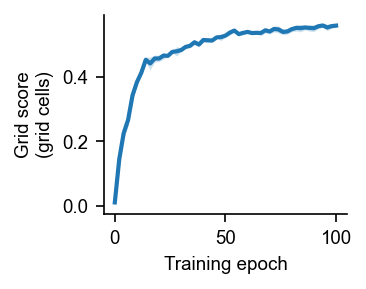

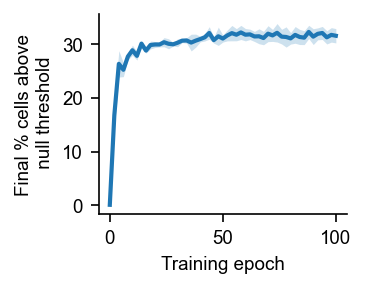

(                    run  threshold  n_grid  frac_grid    Ng
 0  Apr-10-2025-11-08-20   0.355527     197   0.192383  1024
 1  Nov-15-2025-12-40-19   0.355875     184   0.179688  1024
 2  Nov-15-2025-13-44-35   0.355080     200   0.195312  1024,
                     run  epoch  mean_score  sem_score  frac_above_final_null  \
 0  Apr-10-2025-11-08-20      0    0.014301   0.007277               0.000977   
 1  Apr-10-2025-11-08-20      2    0.197344   0.019940               0.219727   
 2  Apr-10-2025-11-08-20      4    0.250036   0.022173               0.297852   
 3  Apr-10-2025-11-08-20      6    0.304888   0.024086               0.276367   
 4  Apr-10-2025-11-08-20      8    0.333050   0.024416               0.266602   
 
    n_final_grid_cells  n_all_cells  
 0                 197         1024  
 1                 197         1024  
 2                 197         1024  
 3                 197         1024  
 4                 197         1024  )

In [21]:
# Track final-null grid cells backward through training.
tracking_rows = []
for run_path in tpc_paths:
    run_name = Path(run_path).name
    grid_cells = final_grid_cells_by_run[run_name]
    threshold = float(final_null_df.loc[final_null_df["run"] == run_name, "threshold"].iloc[0])

    for epoch in EPOCHS:
        all_scores = get_grid_scores(run_path, epoch)
        grid_scores = all_scores[grid_cells]

        tracking_rows.append({
            "run": run_name,
            "epoch": int(epoch),

            # Mean only over cells classified as grid cells at final epoch.
            "mean_score": float(np.nanmean(grid_scores)),
            "sem_score": float(
                np.nanstd(grid_scores, ddof=1) / np.sqrt(np.isfinite(grid_scores).sum())
            ),

            # Fraction over the full population.
            "frac_above_final_null": float(np.nanmean(all_scores > threshold)),

            "n_final_grid_cells": int(len(grid_cells)),
            "n_all_cells": int(len(all_scores)),
    })

final_grid_tracking_df = pd.DataFrame(tracking_rows)

track_summary = (
    final_grid_tracking_df
    .groupby("epoch", as_index=False)
    .agg(
        mean_score=("mean_score", "mean"),
        sem_score=("mean_score", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        frac_mean=("frac_above_final_null", "mean"),
        frac_sem=("frac_above_final_null", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
    )
)

# Plot 1: mean grid score of final-null grid cells tracked backward.
x = track_summary["epoch"].to_numpy()
mean = track_summary["mean_score"].to_numpy()
sem = track_summary["sem_score"].to_numpy()

fig, ax = plt.subplots(figsize=(2.5, 2.))
ax.fill_between(x, mean - sem, mean + sem, color="C0", alpha=0.22, linewidth=0)
ax.plot(x, mean, color="C0", lw=2)
ax.set_xlabel("Training epoch")
ax.set_ylabel("Grid score\n(grid cells)")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
# fig.savefig(FIG_DIR / "tpcn_final_null_grid_score_tracking.pdf", bbox_inches="tight")
plt.show()

# Plot 2: fraction of final-null grid cells exceeding the final null threshold.
frac_mean = 100 * track_summary["frac_mean"].to_numpy()
frac_sem = 100 * track_summary["frac_sem"].to_numpy()

fig, ax = plt.subplots(figsize=(2.5, 2.))
ax.fill_between(x, frac_mean - frac_sem, frac_mean + frac_sem, color="C0", alpha=0.22, linewidth=0)
ax.plot(x, frac_mean, color="C0", lw=2)
ax.set_xlabel("Training epoch")
ax.set_ylabel("Final % cells above\n null threshold")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
# fig.savefig(FIG_DIR / "tpcn_final_null_fraction_tracking.pdf", bbox_inches="tight")
plt.show()

final_null_df, final_grid_tracking_df.head()

In [22]:
saved_score_threshold_rows = []

for run_path in tpc_paths:
    run_name = Path(run_path).name

    threshold = float(
        final_null_df.loc[final_null_df["run"] == run_name, "threshold"].iloc[0]
    )

    final_scores = get_grid_scores(run_path, FINAL_EPOCH)
    is_above = np.asarray(final_scores) > threshold

    saved_score_threshold_rows.append({
        "run": run_name,
        "threshold": threshold,
        "n_above_threshold": int(is_above.sum()),
        "frac_above_threshold": float(is_above.mean()),
        "Ng": int(len(is_above)),
    })

saved_score_threshold_df = pd.DataFrame(saved_score_threshold_rows)
saved_score_threshold_df

,run,threshold,n_above_threshold,frac_above_threshold,Ng
0,Apr-10-2025-11-08-20,0.355527,311,0.303711,1024
1,Nov-15-2025-12-40-19,0.355875,351,0.342773,1024
2,Nov-15-2025-13-44-35,0.355080,309,0.301758,1024


In [23]:
saved_score_threshold_df['n_above_threshold'].mean()

323.6666666666667

## Rat Data: Spatial Stability vs. Grid Score

Digitized from the experimental figure used in the original learning-comparison notebook.

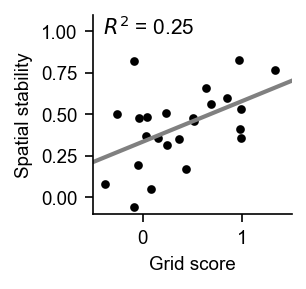

In [24]:
rat_y = [-0.05569620253164557, 0.08354430379746836, 0.05063291139240506, 0.19240506329113924,
0.16835443037974684, 0.3177215189873418, 0.3531645569620253, 0.35443037974683544,
0.3708860759493671, 0.4835443037974684, 0.4746835443037975, 0.5037974683544304,
0.5050632911392405, 0.4569620253164557, 0.47848101265822784, 0.4126582278481013,
0.35822784810126584, 0.5303797468354431, 0.5987341772151898, 0.5632911392405063,
0.660759493670886, 0.8278481012658228, 0.7645569620253164, 0.8202531645569621]
rat_x = [-0.08660844250363897, -0.38064046579330424, 0.08515283842794763, -0.051673944687045115,
0.43449781659388653, 0.24526928675400295, 0.3646288209606987, 0.14919941775836976,
0.029839883551673996, 0.04148471615720528, -0.03711790393013098, -0.2583697234352256,
0.23071324599708887, 0.5131004366812228, 0.5043668122270744, 0.9818049490538574,
0.9934497816593888, 0.9934497816593888, 0.8537117903930131, 0.6906841339155749,
0.6353711790393013, 0.9672489082969433, 1.336972343522562, -0.08660844250363897]

lr = LinearRegression().fit(np.array(rat_x).reshape(-1, 1), rat_y)
rat_fit_x = np.linspace(-0.5, 1.5, 100)
rat_fit_y = lr.predict(rat_fit_x.reshape(-1, 1))
r2 = lr.score(np.array(rat_x).reshape(-1, 1), rat_y)

fig, ax = plt.subplots(figsize=(2.2, 2.0))
ax.scatter(rat_x, rat_y, color="black", s=10)
ax.plot(rat_fit_x, rat_fit_y, color="gray", lw=2)
ax.text(0.05, 0.9, f"$R^2$ = {r2:.2f}", transform=ax.transAxes, fontsize=10)
ax.set_xlabel("Grid score")
ax.set_ylabel("Spatial stability")
ax.set_xlim([-0.5, 1.5])
ax.set_ylim([-0.1, 1.1])
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
# fig.savefig(FIG_DIR / "rat_stability_vs_grid_score.pdf", bbox_inches="tight")
plt.show()

## tPCN: Stability and Grid-Score Evolution

Spatial stability is the correlation between a cell's rate map at the midpoint and endpoint of each training interval. Cells are selected by final grid score, matching the original analysis but without RNN comparison.

In [25]:
N_INTERVALS = 10
INTERVAL_END = 80
n_cells = 32
interval_size = INTERVAL_END // N_INTERVALS
intervals = [(i, i + interval_size) for i in range(0, N_INTERVALS * interval_size, interval_size)]
print("Intervals:", intervals)

# Long-form dataframe because final-null grid-cell counts can differ by run.
stability_rows = []
for run_i, model_path in enumerate(tpc_paths):
    run_name = Path(model_path).name
    grid_cells = np.asarray(selected_cell_ids[run_i], dtype=int)

    for interval_idx, (start_epoch, end_epoch) in enumerate(intervals):
        mid_epoch = (start_epoch + end_epoch) // 2
        rm_mid = np.load(model_path / f"rate_maps_epoch/rate_map_epoch_{mid_epoch}.npy")
        rm_end = np.load(model_path / f"rate_maps_epoch/rate_map_epoch_{end_epoch}.npy")
        scores_mid = get_grid_scores(model_path, mid_epoch)
        scores_end = get_grid_scores(model_path, end_epoch)

        for cell_id in grid_cells:
            a = rm_mid[cell_id].reshape(-1)
            b = rm_end[cell_id].reshape(-1)
            corr = 0.0 if np.std(a) == 0 or np.std(b) == 0 else np.corrcoef(a, b)[0, 1]
            stability_rows.append({
                "run_i": int(run_i),
                "run": run_name,
                "interval_idx": int(interval_idx),
                "start_epoch": int(start_epoch),
                "mid_epoch": int(mid_epoch),
                "end_epoch": int(end_epoch),
                "cell": int(cell_id),
                "stability": float(corr),
                "grid_score": float(0.5 * (scores_mid[cell_id] + scores_end[cell_id])),
            })

stability_cell_df = pd.DataFrame(stability_rows)
display(stability_cell_df.head()), stability_cell_df.groupby("run")["cell"].nunique()

Intervals: [(0, 8), (8, 16), (16, 24), (24, 32), (32, 40), (40, 48), (48, 56), (56, 64), (64, 72), (72, 80)]


,run_i,run,interval_idx,start_epoch,mid_epoch,end_epoch,cell,stability,grid_score
0,0,Apr-10-2025-11-08-20,0,0,4,8,1,0.515298,0.437584
1,0,Apr-10-2025-11-08-20,0,0,4,8,4,0.811967,0.574199
2,0,Apr-10-2025-11-08-20,0,0,4,8,11,0.763886,-0.121650
3,0,Apr-10-2025-11-08-20,0,0,4,8,20,0.715725,0.403237
4,0,Apr-10-2025-11-08-20,0,0,4,8,23,0.290336,0.261307


(None,
 run
 Apr-10-2025-11-08-20    197
 Nov-15-2025-12-40-19    184
 Nov-15-2025-13-44-35    200
 Name: cell, dtype: int64)

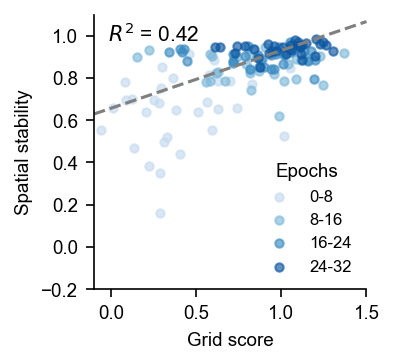

In [26]:
selected_intervals = intervals[:4]
# n_cells = 64
colors = plt.get_cmap("Blues")(np.linspace(0.25, 0.85, len(selected_intervals)))
# select cells with the highest grid scores at 80th epochfrom the first run for visualization
stability_cell_df = stability_cell_df[stability_cell_df["run_i"] == 0]
top_cells_df = (
    stability_cell_df[stability_cell_df["end_epoch"] == 80]
    .nlargest(n_cells, "grid_score")
    .drop_duplicates("cell")
    .copy()
)
top_cells_ids = top_cells_df["cell"].to_numpy()
# select from the stability_cell_df only the top cells
stability_cell_df = stability_cell_df[stability_cell_df["cell"].isin(top_cells_ids)].copy()
fig, ax = plt.subplots(figsize=(2.7, 2.5))
for interval_idx, (start_epoch, end_epoch) in enumerate(selected_intervals):
    sub = stability_cell_df[stability_cell_df["interval_idx"] == interval_idx]
    ax.scatter(
        sub["grid_score"],
        sub["stability"],
        label=f"{start_epoch}-{end_epoch}",
        alpha=0.65,
        s=16,
        color=colors[interval_idx],
    )

all_scores = stability_cell_df["grid_score"].to_numpy()
all_stabilities = stability_cell_df["stability"].to_numpy()
lr_model = LinearRegression().fit(all_scores.reshape(-1, 1), all_stabilities)
x_vals = np.array([-0.1, 1.5])
y_vals = lr_model.predict(x_vals.reshape(-1, 1))
r2 = lr_model.score(all_scores.reshape(-1, 1), all_stabilities)
ax.plot(x_vals, y_vals, color="gray", linestyle="--")
ax.text(0.05, 0.9, f"$R^2$ = {r2:.2f}", transform=ax.transAxes, fontsize=10)

ax.set_xlabel("Grid score")
ax.set_ylabel("Spatial stability")
ax.set_xlim([-0.1, 1.5])
ax.set_ylim([-0.2, 1.1])
ax.spines[["top", "right"]].set_visible(False)
ax.legend(fontsize=8, frameon=False, loc="lower right", title="Epochs")
fig.tight_layout()
# fig.savefig(FIG_DIR / "tpcn_stability_vs_grid_score.pdf", bbox_inches="tight")
plt.show()

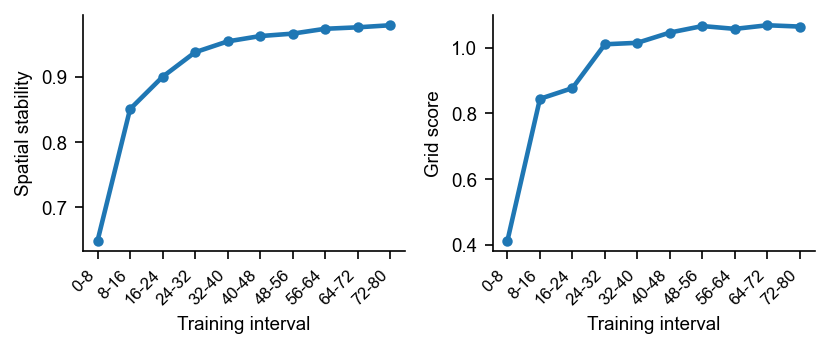

In [27]:
per_run_interval = (
    stability_cell_df
    .groupby(["run", "interval_idx", "start_epoch", "end_epoch"], as_index=False)
    .agg(
        stability_mean=("stability", "mean"),
        grid_score_mean=("grid_score", "mean"),
    )
)

evo_summary = (
    per_run_interval
    .groupby(["interval_idx", "start_epoch", "end_epoch"], as_index=False)
    .agg(
        stability_mean=("stability_mean", "mean"),
        stability_sem=("stability_mean", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        grid_score_mean=("grid_score_mean", "mean"),
        grid_score_sem=("grid_score_mean", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
    )
)

fig, axes = plt.subplots(1, 2, figsize=(5.6, 2.4), sharex=True)
for ax, mean_col, sem_col, ylabel in [
    (axes[0], "stability_mean", "stability_sem", "Spatial stability"),
    (axes[1], "grid_score_mean", "grid_score_sem", "Grid score"),
]:
    x = evo_summary["interval_idx"]
    mean = evo_summary[mean_col]
    sem = evo_summary[sem_col]
    ax.fill_between(x, mean - sem, mean + sem, color="C0", alpha=0.2, linewidth=0)
    ax.plot(x, mean, color="C0", lw=2.2, marker="o", markersize=4)
    ax.set_xlabel("Training interval")
    ax.set_ylabel(ylabel)
    ax.set_xticks(evo_summary["interval_idx"])
    ax.set_xticklabels(
        [f"{s}-{e}" for s, e in zip(evo_summary["start_epoch"], evo_summary["end_epoch"])],
        rotation=45,
        ha="right",
        fontsize=8,
    )
    ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
# fig.savefig(FIG_DIR / "tpcn_stability_score_evolution.pdf", bbox_inches="tight")
plt.show()

## Example RM/SAC Evolution and the Scaffolding Interpretation

The original notebook illustrated cells whose spatial pattern became stable and grid-like over training. For a quantitative scaffoldness metric, possible candidates are:

- **Early stability before high gridness:** mean spatial stability over early intervals while grid score is still below a threshold.
- **Stability-to-gridness lag:** first epoch where stability exceeds a threshold minus first epoch where grid score exceeds a threshold.
- **SAC peak scaffold index:** number/strength of reproducible SAC peaks at early epochs before sixfold symmetry is fully expressed.

No metric is fixed here yet; the cells below are example visualizations for deciding what aspect of scaffoldness we want to formalize.

In [28]:
def find_tpcn_example_cells(stability_cell_df, min_score=1.0, min_stability=0.8, interval_idx=3):
    sub = stability_cell_df[
        (stability_cell_df["interval_idx"] == interval_idx)
        & (stability_cell_df["grid_score"] > min_score)
        & (stability_cell_df["stability"] > min_stability)
    ].copy()
    sub = sub.sort_values(["grid_score", "stability"], ascending=False)
    return list(sub[["run_i", "interval_idx", "cell", "grid_score", "stability"]].itertuples(index=False, name=None))

example_cells = find_tpcn_example_cells(stability_cell_df)
example_cells[:10], len(example_cells)

([(0, 3, 721, 1.3013899814971022, 0.9252408987087468),
  (0, 3, 189, 1.2636199597569422, 0.9571793622281458),
  (0, 3, 981, 1.2422814861104792, 0.9695844592474541),
  (0, 3, 384, 1.229621151666127, 0.9587793474251027),
  (0, 3, 64, 1.2019340193850243, 0.9821882851258247),
  (0, 3, 518, 1.1990753041564224, 0.9035566052286274),
  (0, 3, 815, 1.1455537638462197, 0.9669350423990482),
  (0, 3, 176, 1.1240869184282545, 0.9543899064887595),
  (0, 3, 627, 1.1184626369803683, 0.8840517805037768),
  (0, 3, 421, 1.1137736240914802, 0.912843511286036)],
 19)

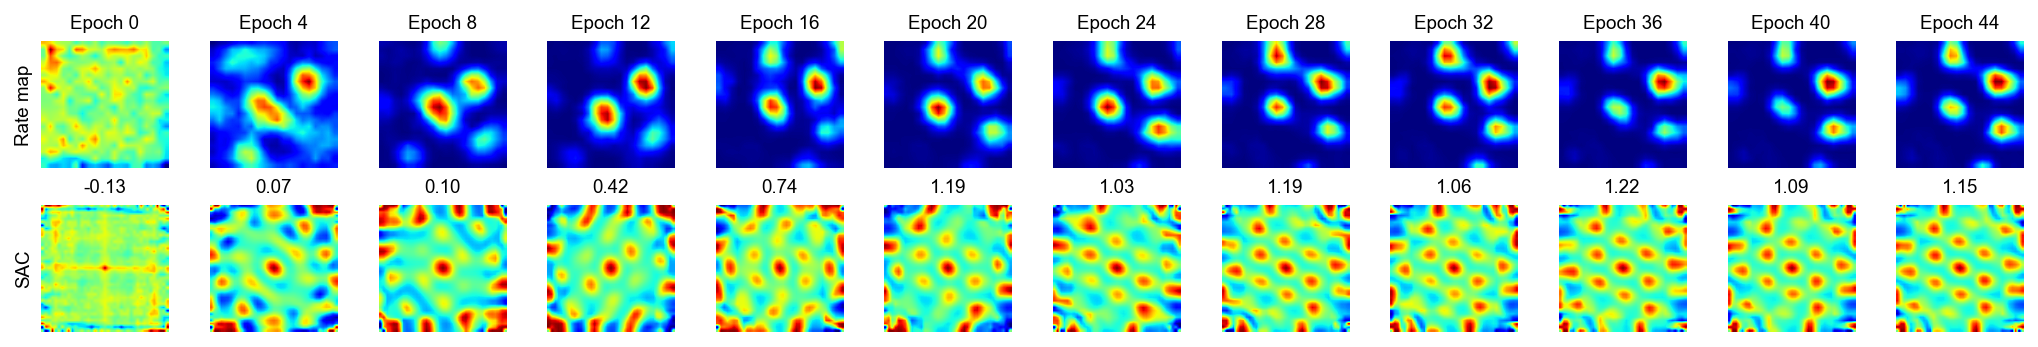

In [44]:
def plot_tpcn_rm_sac_evolution(example, epochs_to_plot=None, save=True):
    run_i, interval_i, cell_id, score, stability = example
    run_path = tpc_paths[int(run_i)]
    cell_id = int(cell_id)

    if epochs_to_plot is None:
        epochs_to_plot = [0, 8, 16, 24, 32, 60, 100]

    epochs_to_plot = list(epochs_to_plot)
    fig, axes = plt.subplots(2, len(epochs_to_plot), figsize=(1.15 * len(epochs_to_plot), 2.35), squeeze=False)

    for j, epoch in enumerate(epochs_to_plot):
        rm = np.load(run_path / f"rate_maps_epoch/rate_map_epoch_{epoch}.npy")[cell_id]
        sac = np.load(run_path / f"sacs/sacs_epoch_{epoch}.npy")[cell_id]
        grid_score = get_grid_scores(run_path, epoch)[cell_id]

        axes[0, j].imshow(normalize_img(rm), cmap="jet", interpolation="bilinear")
        axes[0, j].set_title(f"Epoch {epoch}", fontsize=9)
        clean_ax(axes[0, j])

        axes[1, j].imshow(normalize_img(sac), cmap="jet", interpolation="bilinear")
        axes[1, j].set_title(f"{grid_score:.2f}", fontsize=9)
        clean_ax(axes[1, j])

    axes[0, 0].set_ylabel("Rate map", fontsize=9)
    axes[1, 0].set_ylabel("SAC", fontsize=9)
    fig.tight_layout()

    if save:
        fig.savefig(FIG_DIR / f"tpcn_scaffold_example_run{run_i}_cell{cell_id}.pdf", bbox_inches="tight")
    return fig, axes, cell_id


if len(example_cells):
    plot_tpcn_rm_sac_evolution(example_cells[7], epochs_to_plot=np.arange(0, 48, 4))
else:
    print("No example cells found with current thresholds.")

## Peak Scaffold Similarity and Multipeakness


In [30]:
from scipy.ndimage import gaussian_filter, maximum_filter
from scipy.spatial.distance import cdist


def detect_rate_map_peaks(
    rate_map,
    smooth_sigma=1.0,
    peak_threshold=0.35,
    min_distance=3,
    max_peaks=12,
):
    """Detect local rate-map peaks and return [row, col] coordinates."""
    rm = gaussian_filter(np.asarray(rate_map, dtype=float), sigma=smooth_sigma)
    rm = normalize_img(rm)

    footprint_size = 2 * int(min_distance) + 1
    peak_mask = (rm == maximum_filter(rm, size=footprint_size)) & (rm >= peak_threshold)
    coords_all = np.argwhere(peak_mask)

    if len(coords_all) == 0:
        return np.empty((0, 2), dtype=float)

    strengths = rm[coords_all[:, 0], coords_all[:, 1]]
    order = np.argsort(strengths)[::-1]
    return coords_all[order[:max_peaks]].astype(float)


def soft_peak_scaffold_similarity(peaks_t, peaks_final, sigma=3.0):
    """Soft bidirectional peak-set similarity in [0, 1]."""
    peaks_t = np.asarray(peaks_t, dtype=float)
    peaks_final = np.asarray(peaks_final, dtype=float)
    if len(peaks_t) == 0 or len(peaks_final) == 0:
        return np.nan

    d = cdist(peaks_t, peaks_final)
    t_to_final = np.exp(-(d.min(axis=1) ** 2) / (2 * sigma ** 2)).mean()
    final_to_t = np.exp(-(d.min(axis=0) ** 2) / (2 * sigma ** 2)).mean()
    return float(0.5 * (t_to_final + final_to_t))


def calculate_spatial_gini(grid):
    """
    Spatial Gini coefficient for a 2D rate map.
    Near 1: sparse/concentrated firing fields. Near 0: diffuse/even activity.
    """
    flat_grid = np.asarray(grid, dtype=float).ravel()
    flat_grid = np.nan_to_num(flat_grid, nan=0.0, posinf=0.0, neginf=0.0)
    if np.any(flat_grid < 0):
        flat_grid = flat_grid - np.min(flat_grid)

    sorted_grid = np.sort(flat_grid)
    n = len(sorted_grid)

    if np.sum(sorted_grid) <= 0:
        return 0.0

    index = np.arange(1, n + 1)
    gini = np.sum((2 * index - n - 1) * sorted_grid) / (n * np.sum(sorted_grid))
    return float(gini)


def scaffold_null_for_run(
    run_i,
    epochs=EPOCHS,
    cell_ids=None,
    final_epoch=FINAL_EPOCH,
    n_null=200,
    smooth_sigma=1.0,
    peak_threshold=0.35,
    min_distance=3,
    max_peaks=12,
    match_sigma=3.0,
    seed=0,
):
    """Compute same-cell peak scaffold similarity, shuffled-cell null, and spatial Gini."""
    rng = np.random.default_rng(seed)
    run_path = tpc_paths[run_i]
    run_name = Path(run_path).name
    if cell_ids is None:
        cell_ids = final_grid_cells_by_run[run_name]
    cell_ids = np.asarray(cell_ids, dtype=int)

    final_maps = np.load(run_path / f"rate_maps_epoch/rate_map_epoch_{final_epoch}.npy")
    final_peaks = {}
    for cell in cell_ids:
        final_peaks[int(cell)] = detect_rate_map_peaks(
            final_maps[int(cell)],
            smooth_sigma=smooth_sigma,
            peak_threshold=peak_threshold,
            min_distance=min_distance,
            max_peaks=max_peaks,
        )

    rows = []
    for epoch in epochs:
        maps_t = np.load(run_path / f"rate_maps_epoch/rate_map_epoch_{int(epoch)}.npy")
        scores_t = get_grid_scores(run_path, int(epoch))

        for cell in cell_ids:
            cell = int(cell)
            peaks_t = detect_rate_map_peaks(
                maps_t[cell],
                smooth_sigma=smooth_sigma,
                peak_threshold=peak_threshold,
                min_distance=min_distance,
                max_peaks=max_peaks,
            )
            peaks_final = final_peaks[cell]
            observed = soft_peak_scaffold_similarity(peaks_t, peaks_final, sigma=match_sigma)

            other_cells = cell_ids[cell_ids != cell]
            sampled = rng.choice(other_cells, size=n_null, replace=True)
            null_vals = np.array([
                soft_peak_scaffold_similarity(peaks_t, final_peaks[int(other)], sigma=match_sigma)
                for other in sampled
            ], dtype=float)

            gini_score = calculate_spatial_gini(maps_t[cell])

            rows.append({
                "run_i": int(run_i),
                "run": run_name,
                "epoch": int(epoch),
                "cell": cell,
                "observed": observed,
                "null_mean_cell": float(np.nanmean(null_vals)),
                "null_lo_cell": float(np.nanpercentile(null_vals, 2.5)),
                "null_hi_cell": float(np.nanpercentile(null_vals, 97.5)),
                "grid_score": float(scores_t[cell]),
                "n_peaks_epoch": int(len(peaks_t)),
                "n_final_peaks": int(len(peaks_final)),
                "spatial_gini": gini_score,
            })

    cell_df = pd.DataFrame(rows)
    summary = (
        cell_df
        .groupby(["run_i", "run", "epoch"], as_index=False)
        .agg(
            observed_mean=("observed", "mean"),
            observed_sem=("observed", lambda x: x.std(ddof=1) / np.sqrt(np.isfinite(x).sum())),
            null_mean=("null_mean_cell", "mean"),
            null_lo=("null_lo_cell", "mean"),
            null_hi=("null_hi_cell", "mean"),
            multipeak_mean=("spatial_gini", "mean"),
            multipeak_sem=("spatial_gini", lambda x: x.std(ddof=1) / np.sqrt(np.isfinite(x).sum())),
            grid_score_mean=("grid_score", "mean"),
            grid_score_sem=("grid_score", lambda x: x.std(ddof=1) / np.sqrt(np.isfinite(x).sum())),
            n_epoch_peaks_mean=("n_peaks_epoch", "mean"),
            n_final_peaks_mean=("n_final_peaks", "mean"),
            n_cells=("cell", "nunique"),
        )
    )
    return cell_df, summary



def summarize_scaffold_cell_df(cell_df):
    return (
        cell_df
        .groupby(["run_i", "run", "epoch"], as_index=False)
        .agg(
            observed_mean=("observed", "mean"),
            observed_sem=("observed", lambda x: x.std(ddof=1) / np.sqrt(np.isfinite(x).sum())),
            null_mean=("null_mean_cell", "mean"),
            null_lo=("null_lo_cell", "mean"),
            null_hi=("null_hi_cell", "mean"),
            multipeak_mean=("spatial_gini", "mean"),
            multipeak_sem=("spatial_gini", lambda x: x.std(ddof=1) / np.sqrt(np.isfinite(x).sum())),
            grid_score_mean=("grid_score", "mean"),
            grid_score_sem=("grid_score", lambda x: x.std(ddof=1) / np.sqrt(np.isfinite(x).sum())),
            n_epoch_peaks_mean=("n_peaks_epoch", "mean"),
            n_final_peaks_mean=("n_final_peaks", "mean"),
            n_cells=("cell", "nunique"),
        )
    )


def scaffold_cache_paths(run_i, epochs, n_null, peak_threshold, match_sigma):
    run_name = Path(tpc_paths[run_i]).name
    tag = (
        f"{run_name}_epochs{'-'.join(map(str, map(int, epochs)))}_"
        f"null{n_null}_gini_pth{str(peak_threshold).replace('.', 'p')}_"
        f"ms{str(match_sigma).replace('.', 'p')}"
    )
    cache_dir = FIG_DIR / "peak_scaffold_gini_cache"
    cache_dir.mkdir(parents=True, exist_ok=True)
    return cache_dir / f"{tag}_cells.csv", cache_dir / f"{tag}_summary.csv"


def compute_or_load_scaffold_for_run(run_i, force=False, **kwargs):
    epochs = kwargs.get("epochs", EPOCHS)
    n_null = kwargs.get("n_null", 200)
    peak_threshold = kwargs.get("peak_threshold", 0.35)
    match_sigma = kwargs.get("match_sigma", 3.0)
    cell_cache, summary_cache = scaffold_cache_paths(
        run_i, epochs, n_null, peak_threshold, match_sigma
    )

    if cell_cache.exists() and summary_cache.exists() and not force:
        cell_df = pd.read_csv(cell_cache)
        summary = pd.read_csv(summary_cache)
        return cell_df, summary

    cell_df, summary = scaffold_null_for_run(run_i, **kwargs)
    cell_df.to_csv(cell_cache, index=False)
    summary.to_csv(summary_cache, index=False)
    return cell_df, summary



In [31]:
# Compute once, then edit/re-run plotting cells without recomputing metrics.
import os
os.environ["OMP_NUM_THREADS"] = "6"
SCAFFOLD_EPOCHS = np.arange(0, 110, 10)
SCAFFOLD_KWARGS = dict(
    epochs=SCAFFOLD_EPOCHS,
    n_null=100,
    smooth_sigma=1.0,
    peak_threshold=0.35,
    min_distance=3,
    max_peaks=12,
    match_sigma=3.0,
)

scaffold_metric_outputs = []
for run_i in range(len(tpc_paths)):
    cell_df, summary = compute_or_load_scaffold_for_run(
        run_i,
        force=False,
        seed=run_i,
        **SCAFFOLD_KWARGS,
    )
    scaffold_metric_outputs.append((cell_df, summary))

# Combined tables are useful for stats/export.
scaffold_cell_df = pd.concat([x[0] for x in scaffold_metric_outputs], ignore_index=True)
scaffold_summary_df = pd.concat([x[1] for x in scaffold_metric_outputs], ignore_index=True)
scaffold_summary_df.head()


,run_i,run,epoch,observed_mean,observed_sem,null_mean,null_lo,null_hi,multipeak_mean,multipeak_sem,grid_score_mean,grid_score_sem,n_epoch_peaks_mean,n_final_peaks_mean,n_cells
0,0,Apr-10-2025-11-08-20,0,0.429243,0.008927,0.424888,0.210936,0.623386,0.082091,0.000833,0.014301,0.007277,6.893401,4.634518,197
1,0,Apr-10-2025-11-08-20,10,0.761664,0.009241,0.360883,0.105494,0.636421,0.637217,0.007256,0.386968,0.026273,3.553299,4.634518,197
2,0,Apr-10-2025-11-08-20,20,0.849076,0.007725,0.368457,0.123063,0.624288,0.701291,0.006851,0.476241,0.026780,4.329949,4.634518,197
3,0,Apr-10-2025-11-08-20,30,0.878385,0.007018,0.361917,0.114646,0.621212,0.736605,0.006202,0.487731,0.026147,4.441624,4.634518,197
4,0,Apr-10-2025-11-08-20,40,0.904117,0.006297,0.371185,0.128600,0.620393,0.755568,0.005728,0.513030,0.025521,4.558376,4.634518,197


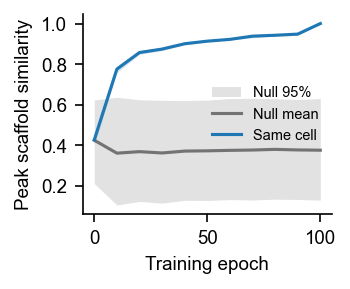

In [32]:
def plot_peak_scaffold_similarity_across_runs(scaffold_summary_df, null_run_i=0, save=True):
    """
    Plot mean observed scaffold similarity across runs.
    Shaded blue = std across runs.
    Gray null = one representative run's null interval/mean.
    """
    per_run = scaffold_summary_df.copy()

    obs_summary = (
        per_run
        .groupby("epoch", as_index=False)
        .agg(
            observed_mean=("observed_mean", "mean"),
            observed_std=("observed_mean", "std"),
        )
    )

    null_summary = (
        per_run[per_run["run_i"] == null_run_i]
        .sort_values("epoch")
        [["epoch", "null_mean", "null_lo", "null_hi"]]
    )

    fig, ax = plt.subplots(figsize=(2.4, 2.))

    ax.fill_between(
        null_summary["epoch"],
        null_summary["null_lo"],
        null_summary["null_hi"],
        color="0.75",
        alpha=0.45,
        linewidth=0,
        label="Null 95%",
    )
    ax.plot(
        null_summary["epoch"],
        null_summary["null_mean"],
        color="0.45",
        lw=1.5,
        label="Null mean",
    )

    obs_lo = obs_summary["observed_mean"] - obs_summary["observed_std"]
    obs_hi = obs_summary["observed_mean"] + obs_summary["observed_std"]

    ax.fill_between(
        obs_summary["epoch"],
        obs_lo,
        obs_hi,
        color="C0",
        alpha=0.2,
        linewidth=0,
        # label="Across-run SD",
    )
    ax.plot(
        obs_summary["epoch"],
        obs_summary["observed_mean"],
        color="C0",
        lw=1.5,
        label="Same cell",
    )

    ax.set_xlabel("Training epoch")
    ax.set_ylabel("Peak scaffold similarity")
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False, fontsize=7, loc="center right")

    fig.tight_layout()

    if save:
        fig.savefig(
            FIG_DIR / "peak_scaffold_similarity_across_runs.pdf",
            bbox_inches="tight",
        )

    plt.show()
    return fig, ax, obs_summary, null_summary

fig, ax, scaffold_obs_summary, scaffold_null_summary = (
    plot_peak_scaffold_similarity_across_runs(scaffold_summary_df, null_run_i=0, save=False)
)

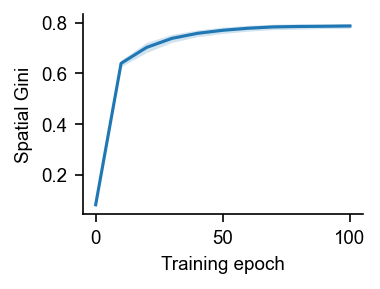

In [33]:
def plot_spatial_gini_across_runs(scaffold_summary_df, save=True):
    """
    Plot mean spatial Gini across runs.
    Shaded green = std across runs.
    """
    gini_summary = (
        scaffold_summary_df
        .groupby("epoch", as_index=False)
        .agg(
            gini_mean=("multipeak_mean", "mean"),
            gini_std=("multipeak_mean", "std"),
        )
    )

    fig, ax = plt.subplots(figsize=(2.6, 2.))

    gini_lo = gini_summary["gini_mean"] - gini_summary["gini_std"]
    gini_hi = gini_summary["gini_mean"] + gini_summary["gini_std"]

    ax.fill_between(
        gini_summary["epoch"],
        gini_lo,
        gini_hi,
        color="C0",
        alpha=0.2,
        linewidth=0,
    )
    ax.plot(
        gini_summary["epoch"],
        gini_summary["gini_mean"],
        color="C0",
        lw=1.5,
    )

    ax.set_xlabel("Training epoch")
    ax.set_ylabel("Spatial Gini")
    ax.spines[["top", "right"]].set_visible(False)

    fig.tight_layout()

    if save:
        fig.savefig(
            FIG_DIR / "spatial_gini_across_runs.pdf",
            bbox_inches="tight",
        )

    plt.show()
    return fig, ax, gini_summary

fig, ax, gini_summary = plot_spatial_gini_across_runs(scaffold_summary_df, save=False)

In [34]:
scaffold_summary_df["run_i"].value_counts()
scaffold_summary_df.groupby("epoch")["run_i"].nunique()

epoch
0      3
10     3
20     3
30     3
40     3
50     3
60     3
70     3
80     3
90     3
100    3
Name: run_i, dtype: int64

In [35]:
(
    scaffold_summary_df
    .groupby("epoch")["observed_mean"]
    .agg(["mean", "std", "min", "max", "count"])
)

,mean,std,min,max,count
epoch,,,,,
0,0.426180,0.023971,0.400825,0.448472,3
10,0.775299,0.016214,0.761664,0.793228,3
20,0.857229,0.008786,0.849076,0.866535,3
30,0.874196,0.007265,0.865807,0.878397,3
40,0.900537,0.005130,0.894659,0.904117,3
50,0.913243,0.001580,0.911522,0.914627,3
60,0.922087,0.002471,0.919718,0.924649,3
70,0.937934,0.008049,0.930348,0.946376,3
80,0.942343,0.003139,0.939461,0.945688,3
